<a href="https://colab.research.google.com/github/1Sayuri/cookie-cats-ab-test/blob/main/cookiecat_ab_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -q "kagglehub[pandas-datasets]"

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "yufengsui/mobile-games-ab-testing",
    "cookie_cats.csv",
)

print("Shape:", df.shape)
df.head()

/tmp/ipykernel_9951/3792126643.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 490k/490k [00:00<00:00, 45.0MB/s]

Extracting zip of cookie_cats.csv...
Shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [4]:
print("Shape:", df.shape)
print("\nGroup sizes:")
print(df['version'].value_counts())
print("\nGroup means:")
print(df.groupby('version')[['sum_gamerounds', 'retention_1', 'retention_7']].mean())

Shape: (90189, 5)

Group sizes:
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Group means:
         sum_gamerounds  retention_1  retention_7
version                                          
gate_30       52.456264     0.448188     0.190201
gate_40       51.298776     0.442283     0.182000


## Hypothesis

- **H₀ (null):** 7-day retention rate is equal for `gate_30` and `gate_40`.
- **H₁ (alternative):** 7-day retention rates differ between the two groups.
- **Metric:** `retention_7` (binary: did the user return 7 days after install?)
- **Test:** Two-proportion z-test, α = 0.05

In [6]:
gate30 = df.loc[df['version'] == 'gate_30', 'retention_7']
gate40 = df.loc[df['version'] == 'gate_40', 'retention_7']

successes = np.array([gate30.sum(), gate40.sum()])
totals    = np.array([len(gate30), len(gate40)])

z_stat, p_value = proportions_ztest(successes, totals)
abs_diff_pp = (gate40.mean() - gate30.mean()) * 100
rel_lift    = (gate40.mean() - gate30.mean()) / gate30.mean() * 100

print(f"gate_30 retention: {gate30.mean():.4f}")
print(f"gate_40 retention: {gate40.mean():.4f}")
print(f"Absolute difference: {abs_diff_pp:+.2f} pp")
print(f"Relative lift:       {rel_lift:+.2f}%")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

gate_30 retention: 0.1902
gate_40 retention: 0.1820
Absolute difference: -0.82 pp
Relative lift:       -4.31%
Z-statistic: 3.1644
P-value:     0.0016


In [7]:
rng = np.random.default_rng(42)   # setting a seed so results are reproducible
n_iter = 2000                     # number of redraws (could go higher but this is an optimal number)

g30 = gate30.to_numpy()
g40 = gate40.to_numpy()

boot_diffs = np.empty(n_iter)     # empty array to store each iteration's gap

for i in range(n_iter):
    # picking 44k players from gate_30 (with replacement), computing their retention
    s30 = rng.choice(g30, size=len(g30), replace=True).mean()
    # same thing for gate_40
    s40 = rng.choice(g40, size=len(g40), replace=True).mean()
    # store the gap for this redraw
    boot_diffs[i] = s40 - s30

# the middle 95% of all redraws = our confidence interval
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% bootstrap CI for (gate_40 - gate_30): [{ci_low:.4f}, {ci_high:.4f}]")
print(f"In percentage points: [{ci_low*100:.2f} pp, {ci_high*100:.2f} pp]")

95% bootstrap CI for (gate_40 - gate_30): [-0.0135, -0.0034]
In percentage points: [-1.35 pp, -0.34 pp]


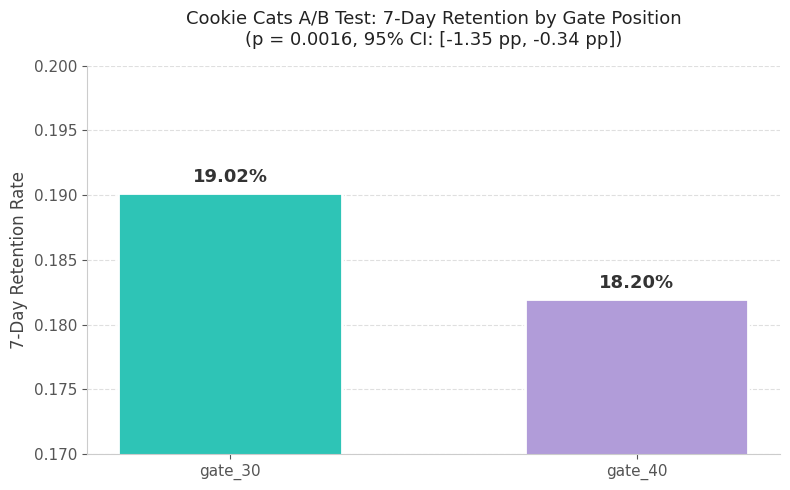

In [10]:
import matplotlib.pyplot as plt

groups = ['gate_30', 'gate_40']
retention_rates = [gate30.mean(), gate40.mean()]

# Pretty palette
lilac = '#B19CD9'
teal  = '#2EC4B6'

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(groups, retention_rates, color=[teal, lilac],
              edgecolor='white', linewidth=2, width=0.55)

# Add the % label on top of each bar
for bar, rate in zip(bars, retention_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0008,
            f'{rate*100:.2f}%',
            ha='center', fontsize=13, fontweight='bold', color='#333')

# Clean up the chart styling
ax.set_ylabel('7-Day Retention Rate', fontsize=12, color='#444')
ax.set_title('Cookie Cats A/B Test: 7-Day Retention by Gate Position\n(p = 0.0016, 95% CI: [-1.35 pp, -0.34 pp])',
             fontsize=13, color='#222', pad=15)
ax.set_ylim(0.17, 0.20)

# Remove the top and right borders (cleaner look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Soft horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)  # gridlines behind bars

# Make tick labels softer
ax.tick_params(colors='#555', labelsize=11)

plt.tight_layout()
plt.savefig('retention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

This experiment tested whether moving the level-progression gate in *Cookie Cats* from level 30 to level 40 would improve 7-day player retention.
It was a common assumption being that delaying friction lets players bond with the game first.

The data tells something different.Players in the `gate_40` group returned to the app at a rate of **18.20%** after 7 days, compared to **19.02%** in the `gate_30` group — a **−0.82 percentage point** drop (−4.31% relative). A two-proportion z-test confirmed the effect is statistically significant (**p = 0.0016**), and a 95% bootstrap confidence interval places the true drop between **−1.35 pp and −0.34 pp**, with zero comfortably outside the range.

**What I'd explore next:** segmenting by `sum_gamerounds` to see whether the gate's effect differs between casual vs. engaged players, and running a power analysis to determine the minimum sample size for detecting smaller effects in future tests.